# Project Budget Prediction with Title and Description

This notebook implements and compares two text-aware models:

1. **CatBoost with native text features**
2. **A multi-input neural network using multilingual sentence embeddings**

Both methods combine `title` and `description` with the existing structured/taxonomy features.

## Important design choices

- The data is split into **train, validation, and untouched test sets**.
- Text preprocessing is fitted only on the training split.
- The target is `log1p(target_budget)`.
- Observed and midpoint-imputed budgets can be evaluated separately.
- Title and description are kept as separate inputs.
- The neural text encoder is frozen; only the regression network is trained.

Update `CSV_PATH` in the configuration cell before running.

In [ ]:
# Run this only if the packages are not installed.
# In Jupyter, uncomment the next line:
# %pip install -q pandas numpy scikit-learn matplotlib catboost tensorflow sentence-transformers joblib

import os
import re
import html
import json
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)


## 1. Configuration

In [ ]:
# Change this path if necessary.
CSV_PATH = Path("../ml_dataset/full_dataset.csv")

# Target construction
REQUIRE_USD_RATE = True
BUDGET_RATIO_THRESHOLD = 3.0
FINAL_BUDGET_MIN_RATIO = 0.80

# Keep the same restricted price range as the original experiment by default.
# Change MAX_PRICE_USD to None to use all valid prices.
MIN_PRICE_USD = 1.0
MAX_PRICE_USD = 100.0

# Split strategy: "random" for direct comparison with the old notebook,
# or "time" for a more realistic future-data evaluation.
SPLIT_STRATEGY = "random"
DATE_COLUMN = "scraped_date_created"

TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

# Neural network settings
TEXT_ENCODER_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
BATCH_SIZE = 64
MAX_EPOCHS = 400

# Weak-label training: midpoint-imputed budgets receive lower weight.
OBSERVED_TARGET_WEIGHT = 1.0
IMPUTED_TARGET_WEIGHT = 0.25

MODEL_DIR = Path("saved_text_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert CSV_PATH.exists(), f"CSV file not found: {CSV_PATH.resolve()}"


## 2. Load and clean the dataset

In [ ]:
df_raw = pd.read_csv(CSV_PATH)

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
display(df_raw.head(2))


Rows: 19,668
Columns: 164


,project_id,title,category,organization,created_at,scraped_date_created,usd_rate,usd_rate_date,final_budget,log_final_budget,final_budget_usd,log_final_budget_usd,budget_min,budget_max,log_budget_min,log_budget_max,budget_min_usd,budget_max_usd,log_budget_min_usd,log_budget_max_usd,budget_range_usd,budget_range_ratio,has_final_budget,duration,duration_days,description_length,description_word_count,skill_count,skills,description,outer_link,Authentication,Authorization & Role Management,User Management,User Profiles,Infrastructure & Operations,Administration Panel,Dashboard,Settings & Configuration,Content Management,Rich Text Editing,Media Management,Forms & Data Collection,File Upload & Storage,Document Management,Search,Filtering & Sorting,Import & Export,Reporting,Analytics,Data Processing,Data Migration,Notifications,Messaging & Chat,Email Services,SMS Services,Video & Voice Communication,Scheduling & Calendar,Workflow Automation,Task Management,Approval Workflow,Payment Processing,Wallet & Balance Management,Shopping Cart & Checkout,Order Management,Inventory Management,Product Catalog,Pricing & Discount Rules,Marketplace,Booking & Reservation,Subscription Management,External API Integration,Payment Gateway Integration,Social Authentication,Map & Geolocation Integration,Hardware Integration,Image Processing,Video Processing,Audio Processing,Streaming,Document Processing,Artificial Intelligence Integration,Recommendation & Personalization,Machine Learning Pipeline,Real-time Updates,Background Jobs,Caching,Offline Support,Data Synchronization,Multi-tenancy,Plugin / Extension System,Localization & Internationalization,Accessibility,Responsive Design,SEO,Security,Audit Logs,Monitoring & Logging,Backup & Recovery,Mobile Application,Web Application,Desktop Application,Browser Extension,Social Features,Comments & Reviews,Gamification,Visualization & Charts,Maps & Spatial Analysis,Scientific & Mathematical Computation,Optimization & Simulation,Web Scraping & Crawling,Bots & Automation,Code Generation & Development Tools,website,web_application,mobile_application,desktop_application,api_backend,ecommerce,marketplace,cms,crm,erp,lms,booking_system,social_network,media_platform,financial_system,healthcare_system,real_estate_platform,automation_system,iot_system,ai_application,browser_extension,other,WordPress,WooCommerce,Joomla,Custom Development,external_api_count,estimated_screens,estimated_entities,real_time,mobile,web,offline,legacy_system,existing_codebase,requires_refactoring,requires_reverse_engineering,cross_platform,project_type,ai_level,business_logic,data_volume,integration_complexity,ui_complexity,algorithmic_complexity,updated_at,category_scraped_id,feature_score_sum,feature_count,feature_score_mean,feature_score_max
0,a6ae2518-7cb9-4915-8629-13090f989342,ساخت بات فروشگاهی تلگرام,پروژه‌های برنامه نویسی,Karlancer,2026-06-25T08:48:44.751434,2026-06-11 05:03:00,179565.00,2026-06-11,500000.0,13.122365,2.784507,1.330916,100000.0,3000000.0,11.512935,14.914123,0.556901,16.707042,0.442698,2.873962,16.150141,30.000000,True,1.0,1.0,129,23,8,python | برنامه نویسی | برنامه نویسی وب | ربات | ساخت ربات | ساخت ربات تلگرام | طراحی ربات | کدنویسی,بات فروشگاهی بدون درگاه پرداخت\nبرای فروش اکانت\nباپنل مدیریت وویرایش کامل محصولات و قیمتها\nپشتیبانی و آموزش کار با بات برای مدیریت,ساخت-بات-فروشگاهی-تلگرام-1n69eo32262o,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,4,3,1,0,1,0,0,0,0,0,0,new,none,medium,small,low,low,low,2026-06-25 08:48:44.751434,6,11,3,0.134146,4
1,2e8ba95c-7051-4099-9e4f-02c85b549ae5,ساخت ربات تلگرام,پروژه‌های برنامه نویسی,Karlancer,2026-06-25T08:48:46.121224,2026-06-02 09:39:53,174628.75,2026-06-02,1500000.0,14.220976,8.589651,2.260684,1500000.0,3500000.0,14.220976,15.068274,8.589651,20.042519,2.260684,3.046545,11.452868,2.333333,True,7.0,7.0,280,55,8,pyt

In [ ]:
def clean_project_text(value):
    """Basic cleaning for mixed Persian/English scraped project text."""
    if pd.isna(value):
        return "__empty__"

    text = html.unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize common Arabic/Persian variants.
    text = text.replace("ي", "ی").replace("ك", "ک")
    text = re.sub(r"\s+", " ", text).strip()

    return text if text else "__empty__"


required_text_columns = ["title", "description"]
missing_text = [c for c in required_text_columns if c not in df_raw.columns]
assert not missing_text, f"Missing text columns: {missing_text}"

df_raw["title_clean"] = df_raw["title"].apply(clean_project_text)
df_raw["description_clean"] = df_raw["description"].apply(clean_project_text)

display(df_raw[["title_clean", "description_clean"]].head())


,title_clean,description_clean
0,ساخت بات فروشگاهی تلگرام,بات فروشگاهی بدون درگاه پرداخت برای فروش اکانت باپنل مدیریت وویرایش کامل محصولات و قیمتها پشتیبانی و آموزش کار با بات برای مدیریت
1,ساخت ربات تلگرام,یک ربات تلگرام میخوام چیز ساده باشه کافیه رسید هارو هم خودم تایید میکنم فقط ربات به مشتری شماره کارت بده و توضیحات رو بفرسته براش هزینه رو که مشتری واریز کرد خودم اکانت رو اماده میکنم داخل ربات ار...
2,رفع مشکل قالب سایت,سلام وقت بخیر من یکی دوتا افزونه راکت و لایت اسپید رو ریختم ولی ظاهرا تنظیمات سایت بهم ریخته یا مشکل از قالب هست میخوام چک بشه در اسرع وقت نهایتا امروز لطفا سرعت لود سایت هم بره بالا ممنون لطفا کس...
3,تکمیل و ویرایش سایت وردپرس,پلاگین هوشمند مدیریت محصول(قابلیت افزایش یا کاهش قیمت به صورت درصد و ثابت هم داره) محصولات نا موجود اخر نمایش داده شوند وصل کردن پنل پیامکی(ارسال پیام سفارش برای مدیر و پیامک های تحویل و ثبت سفارش...
4,طراحی صفحه محاسبه درصد آنلاین در سایت وردپرسی,عرض ادب ، من به یک وردپرس دولوپر نیاز دارم ، یک سایت وردپرسی دارم که کامل طراحی شده ، فقط یک صفحه از سایت مونده که محاسبه درصد آنلاین یک درس در کنکور هست ، عملا یک صفحه میخوام که از قبل هدر و فوتر...


## 3. Rebuild the USD target

In [ ]:
df = df_raw.copy()

if REQUIRE_USD_RATE:
    assert "usd_rate" in df.columns
    df = df[df["usd_rate"].notna()].copy()


def resolve_target_budget(row):
    final_price = row.get("final_budget_usd", np.nan)
    minimum = row.get("budget_min_usd", np.nan)
    maximum = row.get("budget_max_usd", np.nan)

    def valid_price(value):
        if pd.isna(value) or value < MIN_PRICE_USD:
            return False
        if MAX_PRICE_USD is not None and value > MAX_PRICE_USD:
            return False
        return True

    # Use a real final price when it is usable and not implausibly below the listing minimum.
    if valid_price(final_price):
        if pd.isna(minimum) or final_price >= minimum * FINAL_BUDGET_MIN_RATIO:
            return final_price, False

    # Otherwise use midpoint only when the advertised range is narrow enough.
    if pd.notna(minimum) and pd.notna(maximum) and minimum > 0:
        ratio = maximum / minimum
        midpoint = (minimum + maximum) / 2

        if ratio <= BUDGET_RATIO_THRESHOLD and valid_price(midpoint):
            return midpoint, True

    return np.nan, False


resolved = df.apply(
    lambda row: pd.Series(
        resolve_target_budget(row),
        index=["target_budget", "is_budget_imputed"],
    ),
    axis=1,
)

df[["target_budget", "is_budget_imputed"]] = resolved
df = df[df["target_budget"].notna()].copy()

# Duration missingness should be retained as a feature.
if "duration_days" in df.columns:
    df["is_days_null"] = df["duration_days"].isna().astype("int8")
    duration_median = df["duration_days"].median()
    df["duration_days"] = df["duration_days"].fillna(duration_median)

df["log_target_budget"] = np.log1p(df["target_budget"])
df["target_sample_weight"] = np.where(
    df["is_budget_imputed"],
    IMPUTED_TARGET_WEIGHT,
    OBSERVED_TARGET_WEIGHT,
).astype("float32")

print(f"Usable rows: {len(df):,}")
print(f"Observed final budgets: {(~df['is_budget_imputed']).sum():,}")
print(f"Midpoint-imputed budgets: {df['is_budget_imputed'].sum():,}")
print(df["target_budget"].describe())


Usable rows: 13,111
Observed final budgets: 10,848
Midpoint-imputed budgets: 2,263
count    13111.000000
mean        29.252326
std         24.502837
min          1.000403
25%          9.416390
50%         21.117413
75%         41.733808
max         99.944475
Name: target_budget, dtype: float64


## 4. Define structured, categorical, and text features

In [ ]:
TEXT_FEATURES = ["title_clean", "description_clean"]

# Nominal variables should not be ordinal encoded for CatBoost.
CATEGORICAL_CANDIDATES = [
    "category",
    "organization",
    "project_type",
    "ai_level",
    "business_logic",
    "data_volume",
    "integration_complexity",
    "ui_complexity",
    "algorithmic_complexity",
]

# Columns that must never become predictors.
EXCLUDED_COLUMNS = {
    "project_id",
    "title",
    "description",
    "skills",
    "outer_link",
    "created_at",
    "scraped_date_created",
    "updated_at",
    "category_scraped_id",

    "final_budget",
    "log_final_budget",
    "final_budget_usd",
    "log_final_budget_usd",
    "budget_min",
    "budget_max",
    "budget_min_usd",
    "budget_max_usd",
    "log_budget_min",
    "log_budget_max",
    "log_budget_min_usd",
    "log_budget_max_usd",
    "budget_range",
    "budget_range_usd",
    "budget_range_ratio",
    "has_final_budget",

    "usd_rate",
    "usd_rate_date",

    "target_budget",
    "log_target_budget",
    "is_budget_imputed",
    "target_sample_weight",
}

CATEGORICAL_FEATURES = [
    c for c in CATEGORICAL_CANDIDATES
    if c in df.columns and c not in EXCLUDED_COLUMNS
]

NUMERIC_FEATURES = [
    c for c in df.columns
    if c not in EXCLUDED_COLUMNS
    and c not in TEXT_FEATURES
    and c not in CATEGORICAL_FEATURES
    and pd.api.types.is_numeric_dtype(df[c])
]

print("Text features:", TEXT_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Numeric feature count:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES[:30])

# Explicit leakage check
assert "target_budget" not in NUMERIC_FEATURES
assert "log_target_budget" not in NUMERIC_FEATURES
assert "usd_rate" not in NUMERIC_FEATURES


Text features: ['title_clean', 'description_clean']
Categorical features: ['category', 'organization', 'project_type', 'ai_level', 'business_logic', 'data_volume', 'integration_complexity', 'ui_complexity', 'algorithmic_complexity']
Numeric feature count: 130
['duration', 'duration_days', 'description_length', 'description_word_count', 'skill_count', 'Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing', 'Media Management', 'Forms & Data Collection', 'File Upload & Storage', 'Document Management', 'Search', 'Filtering & Sorting', 'Import & Export', 'Reporting', 'Analytics', 'Data Processing', 'Data Migration', 'Notifications', 'Messaging & Chat', 'Email Services', 'SMS Services']


## 5. Train, validation, and untouched test split

In [ ]:
def make_splits(data):
    data = data.copy()

    if SPLIT_STRATEGY == "time":
        assert DATE_COLUMN in data.columns, f"{DATE_COLUMN} not found"
        data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors="coerce")
        data = data.dropna(subset=[DATE_COLUMN]).sort_values(DATE_COLUMN)

        n = len(data)
        train_end = int(n * (1 - VALIDATION_SIZE - TEST_SIZE))
        validation_end = int(n * (1 - TEST_SIZE))

        train_data = data.iloc[:train_end].copy()
        validation_data = data.iloc[train_end:validation_end].copy()
        test_data = data.iloc[validation_end:].copy()

    elif SPLIT_STRATEGY == "random":
        train_data, temporary = train_test_split(
            data,
            test_size=VALIDATION_SIZE + TEST_SIZE,
            random_state=SEED,
        )

        relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)

        validation_data, test_data = train_test_split(
            temporary,
            test_size=relative_test_size,
            random_state=SEED,
        )

    else:
        raise ValueError("SPLIT_STRATEGY must be 'random' or 'time'")

    return train_data, validation_data, test_data


train_df, validation_df, test_df = make_splits(df)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

assert set(train_df.index).isdisjoint(validation_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(validation_df.index).isdisjoint(test_df.index)


Train: (9177, 171)
Validation: (1967, 171)
Test: (1967, 171)


## 6. Shared evaluation utilities

In [ ]:
def evaluate_predictions(y_true_log, y_pred_log, label="Model"):
    y_true_log = np.asarray(y_true_log).reshape(-1)
    y_pred_log = np.asarray(y_pred_log).reshape(-1)

    actual = np.expm1(y_true_log)
    predicted = np.maximum(np.expm1(y_pred_log), 0)

    ratio = np.maximum(
        (predicted + 1e-6) / (actual + 1e-6),
        (actual + 1e-6) / (predicted + 1e-6),
    )

    metrics = {
        "model": label,
        "r2_log": r2_score(y_true_log, y_pred_log),
        "rmse_log": mean_squared_error(y_true_log, y_pred_log) ** 0.5,
        "mae_usd": mean_absolute_error(actual, predicted),
        "within_1.25x": np.mean(ratio <= 1.25),
        "within_1.5x": np.mean(ratio <= 1.50),
        "within_2x": np.mean(ratio <= 2.00),
    }

    return metrics, pd.DataFrame({
        "actual": actual,
        "predicted": predicted,
        "residual": actual - predicted,
        "absolute_error": np.abs(actual - predicted),
        "ratio_error": ratio,
    })


def print_metrics(metrics):
    print(f"\n{metrics['model']}")
    print("-" * len(metrics["model"]))
    print(f"Log R²       : {metrics['r2_log']:.4f}")
    print(f"Log RMSE     : {metrics['rmse_log']:.4f}")
    print(f"Price MAE    : ${metrics['mae_usd']:.2f}")
    print(f"Within 1.25x : {metrics['within_1.25x']:.2%}")
    print(f"Within 1.5x  : {metrics['within_1.5x']:.2%}")
    print(f"Within 2x    : {metrics['within_2x']:.2%}")


def plot_diagnostics(comparison, title):
    # Actual vs predicted
    plt.figure(figsize=(7, 6))
    plt.scatter(comparison["actual"], comparison["predicted"], alpha=0.20, s=14)
    upper = max(comparison["actual"].max(), comparison["predicted"].max())
    plt.plot([0, upper], [0, upper], linestyle="--")
    plt.xlabel("Actual price (USD)")
    plt.ylabel("Predicted price (USD)")
    plt.title(f"{title}: actual vs predicted")
    plt.tight_layout()
    plt.show()

    # Residual vs actual
    plt.figure(figsize=(7, 5))
    plt.scatter(comparison["actual"], comparison["residual"], alpha=0.20, s=14)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Actual price (USD)")
    plt.ylabel("Residual: actual - predicted")
    plt.title(f"{title}: residuals")
    plt.tight_layout()
    plt.show()

    # Calibration by predicted-price decile
    calibration = comparison.copy()
    calibration["predicted_bin"] = pd.qcut(
        calibration["predicted"],
        q=10,
        duplicates="drop",
    )

    calibration = calibration.groupby(
        "predicted_bin",
        observed=True,
    ).agg(
        mean_actual=("actual", "mean"),
        mean_predicted=("predicted", "mean"),
        count=("actual", "size"),
    ).reset_index()

    plt.figure(figsize=(7, 6))
    plt.plot(calibration["mean_predicted"], calibration["mean_actual"], marker="o")
    upper = max(
        calibration["mean_actual"].max(),
        calibration["mean_predicted"].max(),
    )
    plt.plot([0, upper], [0, upper], linestyle="--")
    plt.xlabel("Mean predicted price")
    plt.ylabel("Mean actual price")
    plt.title(f"{title}: calibration by prediction decile")
    plt.tight_layout()
    plt.show()

    display(calibration)


# Method 1 — CatBoost with native text features

This model receives:

- title text;
- description text;
- native categorical variables;
- numeric/taxonomy variables.

CatBoost builds text statistics internally. No external embedding model is needed.

In [ ]:
from catboost import CatBoostRegressor, Pool

# CatBoost requires missing categorical/text values to be converted to strings.
for split in [train_df, validation_df, test_df]:
    for column in TEXT_FEATURES:
        split[column] = split[column].fillna("__empty__").astype(str)

    for column in CATEGORICAL_FEATURES:
        split[column] = split[column].fillna("__missing__").astype(str)

    for column in NUMERIC_FEATURES:
        split[column] = pd.to_numeric(split[column], errors="coerce")

numeric_medians = train_df[NUMERIC_FEATURES].median()

for split in [train_df, validation_df, test_df]:
    split[NUMERIC_FEATURES] = split[NUMERIC_FEATURES].fillna(numeric_medians)

CATBOOST_FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
    + TEXT_FEATURES
)

train_pool = Pool(
    train_df[CATBOOST_FEATURES],
    label=train_df["log_target_budget"],
    weight=train_df["target_sample_weight"],
    cat_features=CATEGORICAL_FEATURES,
    text_features=TEXT_FEATURES,
)

validation_pool = Pool(
    validation_df[CATBOOST_FEATURES],
    label=validation_df["log_target_budget"],
    weight=validation_df["target_sample_weight"],
    cat_features=CATEGORICAL_FEATURES,
    text_features=TEXT_FEATURES,
)

test_pool = Pool(
    test_df[CATBOOST_FEATURES],
    label=test_df["log_target_budget"],
    cat_features=CATEGORICAL_FEATURES,
    text_features=TEXT_FEATURES,
)


In [ ]:
catboost_text_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=10,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=SEED,
    early_stopping_rounds=200,
    verbose=100,
    allow_writing_files=False,
)

catboost_text_model.fit(
    train_pool,
    eval_set=validation_pool,
    use_best_model=True,
)

catboost_pred_test_log = catboost_text_model.predict(test_pool)

catboost_metrics, catboost_comparison = evaluate_predictions(
    test_df["log_target_budget"],
    catboost_pred_test_log,
    label="CatBoost native text",
)

print_metrics(catboost_metrics)


0:	learn: 0.8882020	test: 0.8751201	best: 0.8751201 (0)	total: 474ms	remaining: 39m 28s
100:	learn: 0.7376975	test: 0.7233792	best: 0.7233792 (100)	total: 30.1s	remaining: 24m 18s
200:	learn: 0.7160816	test: 0.7066174	best: 0.7066174 (200)	total: 54s	remaining: 21m 30s
300:	learn: 0.7073942	test: 0.7016663	best: 0.7016663 (300)	total: 1m 12s	remaining: 18m 55s
400:	learn: 0.7010197	test: 0.6991266	best: 0.6991266 (400)	total: 1m 32s	remaining: 17m 40s
500:	learn: 0.6943786	test: 0.6965560	best: 0.6965483 (499)	total: 1m 53s	remaining: 16m 56s
600:	learn: 0.6873172	test: 0.6947836	best: 0.6947795 (595)	total: 2m 14s	remaining: 16m 22s
700:	learn: 0.6806093	test: 0.6939231	best: 0.6938711 (689)	total: 2m 32s	remaining: 15m 37s
800:	learn: 0.6740490	test: 0.6929430	best: 0.6929379 (797)	total: 2m 50s	remaining: 14m 55s
900:	learn: 0.6678588	test: 0.6922405	best: 0.6922282 (897)	total: 3m 8s	remaining: 14m 16s
1000:	learn: 0.6623490	test: 0.6917483	best: 0.6917347 (998)	total: 3m 29s	remai

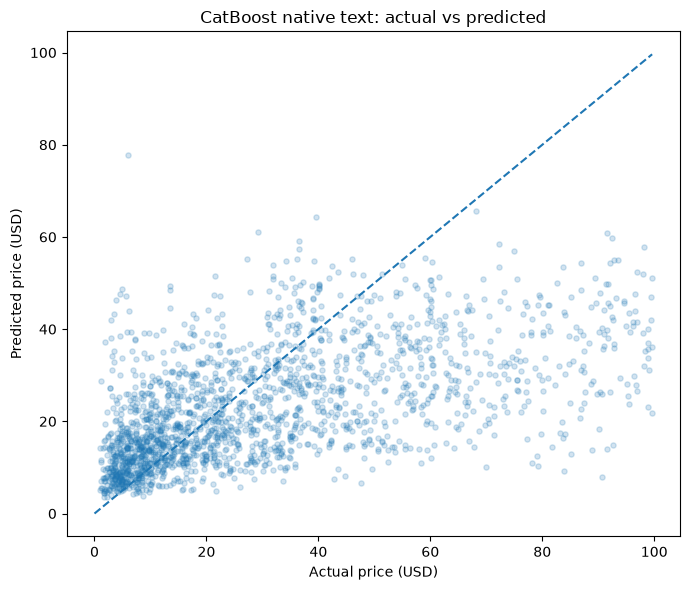

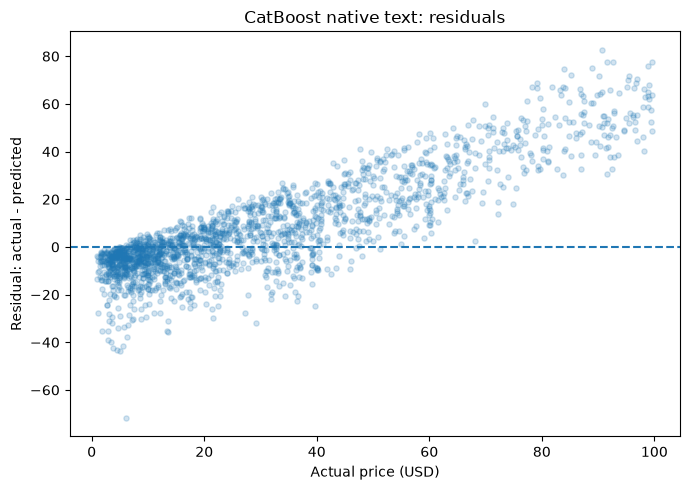

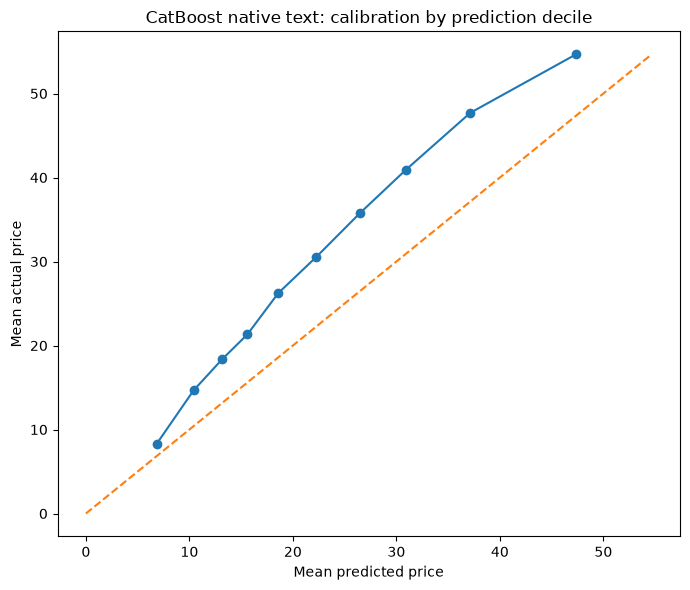

,predicted_bin,mean_actual,mean_predicted,count
0,"(3.492, 8.843]",8.328067,6.855365,197
1,"(8.843, 11.867]",14.670626,10.411599,197
2,"(11.867, 14.438]",18.371353,13.169484,196
3,"(14.438, 16.921]",21.321865,15.600092,197
4,"(16.921, 20.2]",26.246827,18.593565,197
5,"(20.2, 24.37]",30.522349,22.242976,196
6,"(24.37, 28.594]",35.740995,26.460263,197
7,"(28.594, 33.55]",40.924361,30.921270,196
8,"(33.55, 40.746]",47.702906,37.142460,197
9,"(40.746, 77.858]",54.672530,47.367828,197


In [ ]:
plot_diagnostics(catboost_comparison, "CatBoost native text")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_random(comparison, title="Random"):
    actual = comparison["actual"].to_numpy()

    # Random y-values between 0 and max(actual)
    random_y = np.random.uniform(
        low=0,
        high=actual.max(),
        size=len(actual)
    )

    plt.figure(figsize=(7, 6))
    plt.scatter(actual, random_y, alpha=0.20, s=14)
    plt.xlabel("Actual price (USD)")
    plt.ylabel("Random values")
    plt.title(f"{title}: actual vs random")
    plt.tight_layout()
    plt.show()

    print("hi")
    plot_random(catboost_comparison, "CatBoost native text random")
    print("bye")

### Evaluate observed and midpoint-imputed targets separately

In [ ]:
for subset_name, subset_mask in {
    "Observed targets": ~test_df["is_budget_imputed"].to_numpy(),
    "Imputed targets": test_df["is_budget_imputed"].to_numpy(),
}.items():
    if subset_mask.sum() == 0:
        continue

    subset_metrics, _ = evaluate_predictions(
        test_df.loc[subset_mask, "log_target_budget"],
        catboost_pred_test_log[subset_mask],
        label=f"CatBoost — {subset_name}",
    )
    print_metrics(subset_metrics)



CatBoost — Observed targets
---------------------------
Log R²       : 0.3467
Log RMSE     : 0.7209
Price MAE    : $14.24
Within 1.25x : 21.10%
Within 1.5x  : 38.39%
Within 2x    : 61.73%

CatBoost — Imputed targets
--------------------------
Log R²       : 0.3095
Log RMSE     : 0.6683
Price MAE    : $19.08
Within 1.25x : 27.99%
Within 1.5x  : 47.17%
Within 2x    : 70.44%


In [ ]:
catboost_text_model.save_model(
    str(MODEL_DIR / "catboost_native_text.cbm")
)

joblib.dump(
    {
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "text_features": TEXT_FEATURES,
        "numeric_medians": numeric_medians,
    },
    MODEL_DIR / "catboost_feature_config.joblib",
)

print("CatBoost model saved.")


CatBoost model saved.


# Method 2 — Multi-input neural network with sentence embeddings

The frozen multilingual encoder converts title and description into dense vectors.

The network then uses three branches:

1. structured numeric/categorical branch;
2. title-embedding branch;
3. description-embedding branch.

The branches are concatenated before predicting log price.

> The first execution may need internet access to download the sentence-transformer model.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sentence_transformers import SentenceTransformer

tf.random.set_seed(SEED)

text_encoder = SentenceTransformer(TEXT_ENCODER_NAME)


def encode_text(dataframe, column):
    return text_encoder.encode(
        dataframe[column].fillna("__empty__").astype(str).tolist(),
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype("float32")


title_train = encode_text(train_df, "title_clean")
title_validation = encode_text(validation_df, "title_clean")
title_test = encode_text(test_df, "title_clean")

description_train = encode_text(train_df, "description_clean")
description_validation = encode_text(validation_df, "description_clean")
description_test = encode_text(test_df, "description_clean")

print("Title embedding:", title_train.shape)
print("Description embedding:", description_train.shape)


Batches: 100%|██████████| 31/31 [00:03<00:00,  9.19it/s]


Title embedding: (9177, 384)
Description embedding: (9177, 384)


## Prepare structured inputs for the neural network

In [ ]:
# Neural networks require all inputs to be numeric.
# One-hot encoding is fitted on train and aligned across validation/test.

structured_train = pd.concat(
    [
        train_df[NUMERIC_FEATURES],
        pd.get_dummies(
            train_df[CATEGORICAL_FEATURES],
            prefix=CATEGORICAL_FEATURES,
            dtype="float32",
        ),
    ],
    axis=1,
)

structured_validation = pd.concat(
    [
        validation_df[NUMERIC_FEATURES],
        pd.get_dummies(
            validation_df[CATEGORICAL_FEATURES],
            prefix=CATEGORICAL_FEATURES,
            dtype="float32",
        ),
    ],
    axis=1,
)

structured_test = pd.concat(
    [
        test_df[NUMERIC_FEATURES],
        pd.get_dummies(
            test_df[CATEGORICAL_FEATURES],
            prefix=CATEGORICAL_FEATURES,
            dtype="float32",
        ),
    ],
    axis=1,
)

structured_validation = structured_validation.reindex(
    columns=structured_train.columns,
    fill_value=0,
)

structured_test = structured_test.reindex(
    columns=structured_train.columns,
    fill_value=0,
)

structured_medians = structured_train.median()

structured_train = structured_train.fillna(structured_medians)
structured_validation = structured_validation.fillna(structured_medians)
structured_test = structured_test.fillna(structured_medians)

structured_scaler = StandardScaler()

numeric_train_nn = structured_scaler.fit_transform(
    structured_train
).astype("float32")

numeric_validation_nn = structured_scaler.transform(
    structured_validation
).astype("float32")

numeric_test_nn = structured_scaler.transform(
    structured_test
).astype("float32")

y_train = train_df["log_target_budget"].to_numpy(dtype="float32")
y_validation = validation_df["log_target_budget"].to_numpy(dtype="float32")
y_test = test_df["log_target_budget"].to_numpy(dtype="float32")

weight_train = train_df["target_sample_weight"].to_numpy(dtype="float32")
weight_validation = validation_df["target_sample_weight"].to_numpy(dtype="float32")

print("Structured neural input:", numeric_train_nn.shape)


Structured neural input: (9177, 159)


## Build and train the multi-input neural network

In [ ]:
def build_multimodal_regressor(
    numeric_dim,
    title_dim,
    description_dim,
):
    l2 = regularizers.l2(1e-4)

    numeric_input = keras.Input(
        shape=(numeric_dim,),
        name="numeric_features",
    )
    title_input = keras.Input(
        shape=(title_dim,),
        name="title_embedding",
    )
    description_input = keras.Input(
        shape=(description_dim,),
        name="description_embedding",
    )

    numeric_branch = layers.Dense(
        256,
        activation="gelu",
        kernel_regularizer=l2,
    )(numeric_input)
    numeric_branch = layers.BatchNormalization()(numeric_branch)
    numeric_branch = layers.Dropout(0.20)(numeric_branch)
    numeric_branch = layers.Dense(64, activation="gelu")(numeric_branch)

    title_branch = layers.Dense(64, activation="gelu")(title_input)
    title_branch = layers.Dropout(0.15)(title_branch)
    title_branch = layers.Dense(48, activation="gelu")(title_branch)

    description_branch = layers.Dense(
        192,
        activation="gelu",
    )(description_input)
    description_branch = layers.Dropout(0.25)(description_branch)
    description_branch = layers.Dense(
        96,
        activation="gelu",
    )(description_branch)

    combined = layers.Concatenate()(
        [numeric_branch, title_branch, description_branch]
    )

    combined = layers.Dense(
        128,
        activation="gelu",
        kernel_regularizer=l2,
    )(combined)
    combined = layers.Dropout(0.30)(combined)
    combined = layers.Dense(64, activation="gelu")(combined)
    combined = layers.Dropout(0.20)(combined)
    combined = layers.Dense(64, activation="gelu")(combined)

    output = layers.Dense(
        1,
        name="predicted_log_price",
    )(combined)

    model = keras.Model(
        inputs=[
            numeric_input,
            title_input,
            description_input,
        ],
        outputs=output,
        name="project_budget_multimodal_regressor",
    )

    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=1e-4,
            weight_decay=1e-6,
        ),
        loss=keras.losses.Huber(delta=0.5),
        metrics=[
            keras.metrics.MeanAbsoluteError(name="log_mae"),
            keras.metrics.RootMeanSquaredError(name="log_rmse"),
        ],
    )

    return model


nn_model = build_multimodal_regressor(
    numeric_train_nn.shape[1],
    title_train.shape[1],
    description_train.shape[1],
)

nn_model.summary()


Model: "project_budget_multimodal_regressor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numeric_features    │ (None, 159)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_90 (Dense)    │ (None, 256)       │     40,960 │ numeric_features… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ title_embedding     │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ description_embedd… │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_90[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_92 (Dense)    │ (None, 64)        │     24,640 │ title_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_94 (Dense)    │ (None, 192)       │     73,920 │ description_embe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_50          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_51          │ (None, 64)        │          0 │ dense_92[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 192)       │          0 │ dense_94[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_91 (Dense)    │ (None, 64)        │     16,448 │ dropout_50[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_93 (Dense)    │ (None, 48)        │      3,120 │ dropout_51[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_95 (Dense)    │ (None, 96)        │     18,528 │ dropout_52[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 208)       │          0 │ dense_91[0][0],   │
│ (Concatenate)       │                   │            │ dense_93[0][0],   │
│                     │                   │            │ dense_95[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_96 (Dense)    │ (None, 128)       │     26,752 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 128)       │          0 │ dense_96[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_97 (Dense)    │ (None, 64)        │      8,256 │ dropout_53[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 64)        │          0 │ dense_97[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_98 (Dense)    │ (None, 64)        │      4,160 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 217,873 (851.07 KB)

 Trainable params: 217,361 (849.07 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
nn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-4,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_DIR / "best_multimodal_nn.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

nn_history = nn_model.fit(
    {
        "numeric_features": numeric_train_nn,
        "title_embedding": title_train,
        "description_embedding": description_train,
    },
    y_train,
    sample_weight=weight_train,
    validation_data=(
        {
            "numeric_features": numeric_validation_nn,
            "title_embedding": title_validation,
            "description_embedding": description_validation,
        },
        y_validation,
        weight_validation,
    ),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=nn_callbacks,
    verbose=1,
)


Epoch 1/400
144/144 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - log_mae: 1.8260 - log_rmse: 2.1735 - loss: 0.7072 - val_log_mae: 1.0414 - val_log_rmse: 1.2509 - val_loss: 0.3649 - learning_rate: 1.0000e-04
Epoch 2/400
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - log_mae: 0.8019 - log_rmse: 1.0030 - loss: 0.2848 - val_log_mae: 0.7432 - val_log_rmse: 0.9035 - val_loss: 0.2489 - learning_rate: 1.0000e-04
Epoch 3/400
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - log_mae: 0.7389 - log_rmse: 0.9194 - loss: 0.2575 - val_log_mae: 0.6935 - val_log_rmse: 0.8434 - val_loss: 0.2311 - learning_rate: 1.0000e-04
Epoch 4/400
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - log_mae: 0.7080 - log_rmse: 0.8841 - loss: 0.2448 - val_log_mae: 0.6786 - val_log_rmse: 0.8229 - val_loss: 0.2252 - learning_rate: 1.0000e-04
Epoch 5/400
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - log_mae: 0.6842 - log_rmse: 0.8532 - loss: 0.2346 - val_log_mae: 0.6725 - val_log_rmse: 0.8148 - val_loss: 0.2224 - learning_rate: 1.0000e-04
Epoch 6/400
14

## Neural-network training curve and evaluation

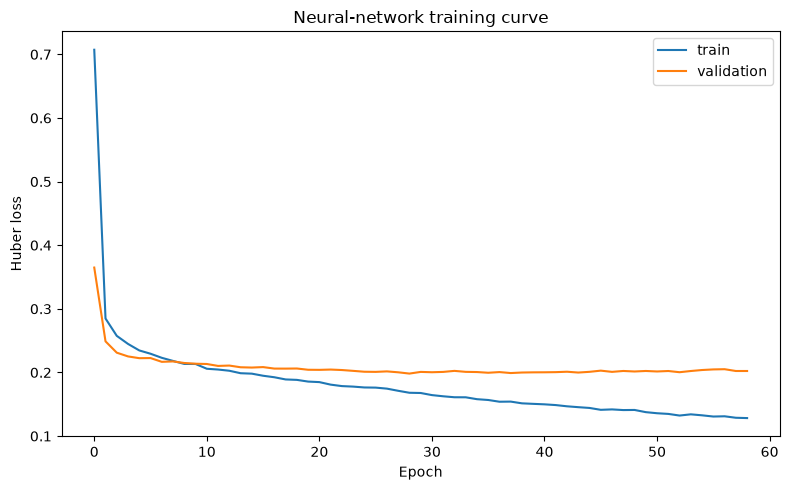


Multimodal neural network
-------------------------
Log R²       : 0.2778
Log RMSE     : 0.7698
Price MAE    : $16.27
Within 1.25x : 20.74%
Within 1.5x  : 36.71%
Within 2x    : 58.82%


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(nn_history.history["loss"], label="train")
plt.plot(nn_history.history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.title("Neural-network training curve")
plt.legend()
plt.tight_layout()
plt.show()

nn_pred_test_log = nn_model.predict(
    {
        "numeric_features": numeric_test_nn,
        "title_embedding": title_test,
        "description_embedding": description_test,
    },
    batch_size=BATCH_SIZE,
    verbose=0,
).reshape(-1)

nn_metrics, nn_comparison = evaluate_predictions(
    y_test,
    nn_pred_test_log,
    label="Multimodal neural network",
)

print_metrics(nn_metrics)


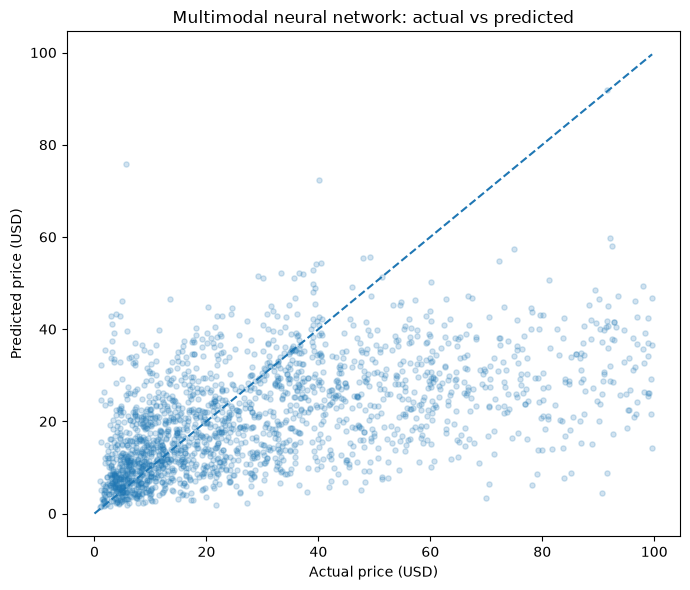

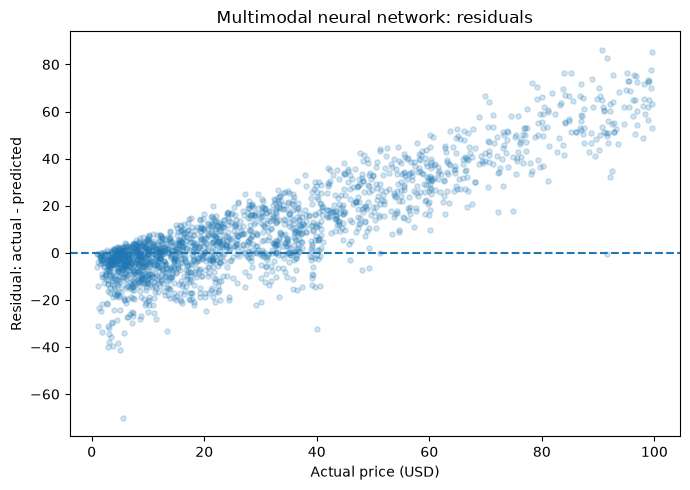

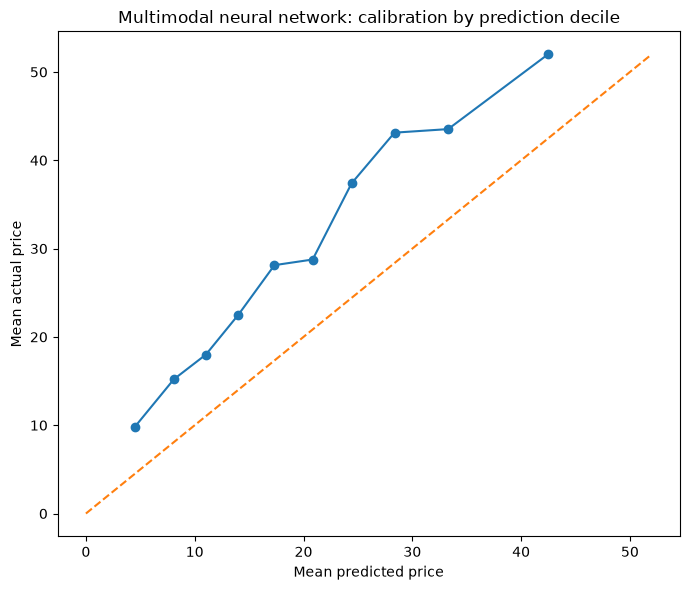

,predicted_bin,mean_actual,mean_predicted,count
0,"(1.405, 6.535]",9.845989,4.517622,197
1,"(6.535, 9.59]",15.204122,8.083419,197
2,"(9.59, 12.405]",17.998047,11.027543,196
3,"(12.405, 15.573]",22.504070,14.008116,197
4,"(15.573, 19.022]",28.125793,17.328732,197
5,"(19.022, 22.471]",28.764040,20.840704,196
6,"(22.471, 26.383]",37.396652,24.422207,197
7,"(26.383, 30.363]",43.129345,28.362753,196
8,"(30.363, 36.402]",43.531509,33.292835,197
9,"(36.402, 91.876]",52.002682,42.474846,197


In [ ]:
plot_diagnostics(nn_comparison, "Multimodal neural network")


In [ ]:
for subset_name, subset_mask in {
    "Observed targets": ~test_df["is_budget_imputed"].to_numpy(),
    "Imputed targets": test_df["is_budget_imputed"].to_numpy(),
}.items():
    if subset_mask.sum() == 0:
        continue

    subset_metrics, _ = evaluate_predictions(
        y_test[subset_mask],
        nn_pred_test_log[subset_mask],
        label=f"Neural network — {subset_name}",
    )
    print_metrics(subset_metrics)



Neural network — Observed targets
---------------------------------
Log R²       : 0.1479
Log RMSE     : 0.8233
Price MAE    : $15.37
Within 1.25x : 19.65%
Within 1.5x  : 35.35%
Within 2x    : 57.97%

Neural network — Imputed targets
--------------------------------
Log R²       : 0.0876
Log RMSE     : 0.7683
Price MAE    : $21.11
Within 1.25x : 22.01%
Within 1.5x  : 39.94%
Within 2x    : 66.04%


In [ ]:
nn_model.save(MODEL_DIR / "multimodal_nn_final.keras")

joblib.dump(
    {
        "structured_columns": structured_train.columns.tolist(),
        "structured_medians": structured_medians,
        "structured_scaler": structured_scaler,
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "text_encoder_name": TEXT_ENCODER_NAME,
    },
    MODEL_DIR / "neural_preprocessing.joblib",
)

print("Neural network and preprocessing objects saved.")


Neural network and preprocessing objects saved.


# 7. Compare both methods

In [ ]:
results = pd.DataFrame([
    catboost_metrics,
    nn_metrics,
]).set_index("model")

display(
    results.style.format({
        "r2_log": "{:.4f}",
        "rmse_log": "{:.4f}",
        "mae_usd": "${:.2f}",
        "within_1.25x": "{:.2%}",
        "within_1.5x": "{:.2%}",
        "within_2x": "{:.2%}",
    })
)


,r2_log,rmse_log,mae_usd,within_1.25x,within_1.5x,within_2x
model,,,,,,
CatBoost native text,0.3810,0.7127,$15.02,22.22%,39.81%,63.14%
Multimodal neural network,0.3004,0.7576,$15.51,23.74%,38.89%,62.48%


## Optional validation-weighted ensemble


CatBoost + neural ensemble
--------------------------
Log R²       : 0.3870
Log RMSE     : 0.7092
Price MAE    : $14.93
Within 1.25x : 23.39%
Within 1.5x  : 40.98%
Within 2x    : 64.06%


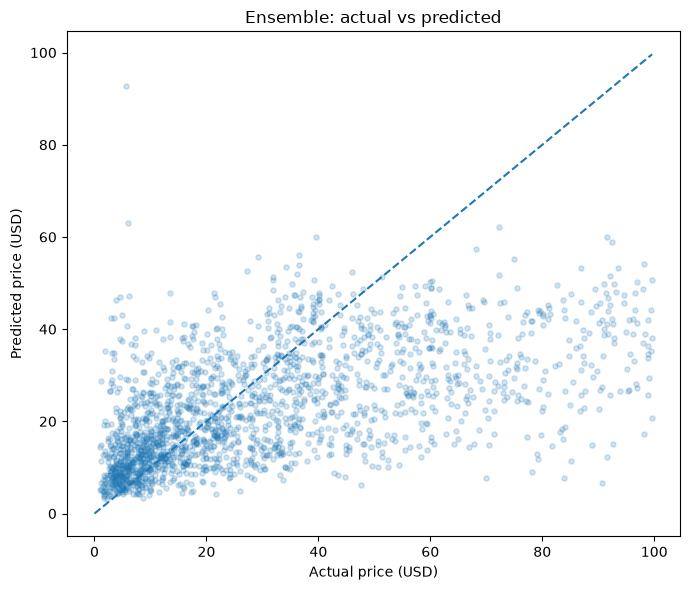

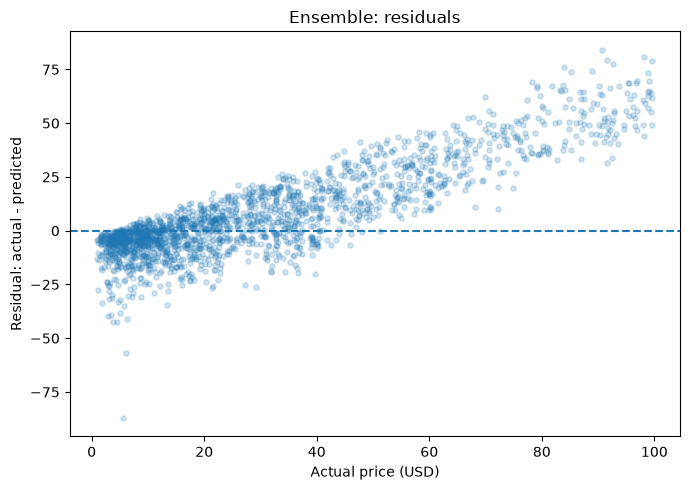

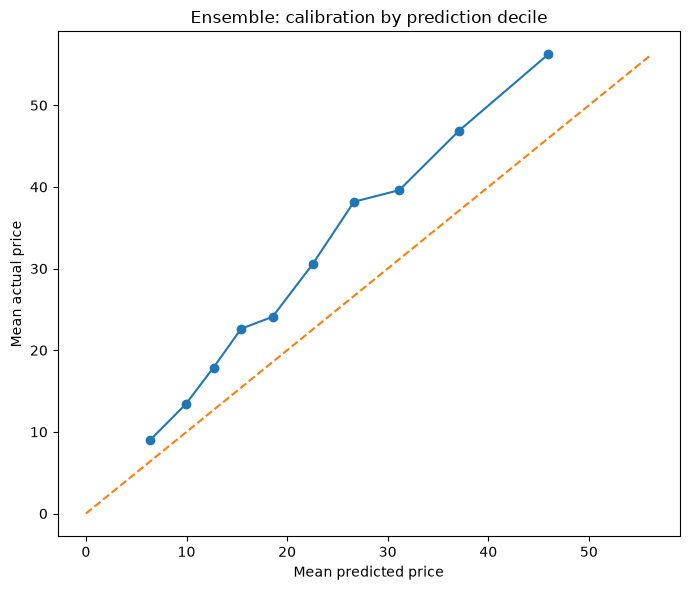

,predicted_bin,mean_actual,mean_predicted,count
0,"(3.2, 8.364]",8.998028,6.388147,197
1,"(8.364, 11.323]",13.387077,9.917688,197
2,"(11.323, 14.164]",17.878902,12.686971,196
3,"(14.164, 16.836]",22.639629,15.438725,197
4,"(16.836, 20.558]",24.089346,18.552186,197
5,"(20.558, 24.634]",30.563696,22.547481,196
6,"(24.634, 28.685]",38.186684,26.652167,197
7,"(28.685, 33.76]",39.607548,31.150789,196
8,"(33.76, 40.611]",46.896900,37.099263,197
9,"(40.611, 92.695]",56.245098,45.964691,197


In [ ]:
# A simple ensemble may improve performance because the models learn different signals.
# The weight must be chosen using validation results, not test results.

CATBOOST_WEIGHT = 0.70
NN_WEIGHT = 0.30

ensemble_pred_test_log = (
    CATBOOST_WEIGHT * catboost_pred_test_log
    + NN_WEIGHT * nn_pred_test_log
)

ensemble_metrics, ensemble_comparison = evaluate_predictions(
    y_test,
    ensemble_pred_test_log,
    label="CatBoost + neural ensemble",
)

print_metrics(ensemble_metrics)
plot_diagnostics(ensemble_comparison, "Ensemble")


# 8. Suggested ablation experiments

Run these with the same split:

- structured features only;
- title only;
- description only;
- title + description;
- structured + title + description;
- observed targets only;
- observed + downweighted imputed targets;
- random split versus chronological split.

A model improvement is meaningful only when it improves the untouched test set and remains stable across these experiments.